# Install libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from firthlogist import FirthLogisticRegression
from sklearn.utils.validation import check_X_y
import warnings

# To resolve the patched_validate issue (Required for Firth in Python 3.10 / newer scikit-learn)

In [19]:
def patched_validate(self, X, y, **kwargs):
    return check_X_y(X, y, **kwargs)
FirthLogisticRegression._validate_data = patched_validate

# Opening cleaned PAROS dataset

In [20]:
CURRENT_DIRECTORY = Path.cwd().resolve()

# Find project root that contains datasets
PROJECT_ROOT = next(
    p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents]
    if (p / "datasets").exists()
)

CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"

if not CLEANED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Cleaned dataset not found: {CLEANED_DATASET_PATH}")

df = pd.read_csv(CLEANED_DATASET_PATH)
print(f"Loaded cleaned PAROS dataset: {df.shape}")
display(df.head(3))

Loaded cleaned PAROS dataset: (2039, 71)


,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,Age,Age Modifier,Gender,Race,...,Outcome of patient,Patient status,Date of Discharge or Death,Patient neurological status - Cerebral,Patient neurological status - Overall,Patient neurological status - Unknown,Year,Call_Time,Shock_Time,Time_to_Defib
0,Ems,2014-01-01,238889.0,NaN,Transport Center,Dhoby Ghaut Mrt Level B1,59,Years,Male,Chinese,...,Died In Ed,NaN,NaN,NaN,5.0,NaN,2014,2026-04-06 22:28:12,2026-04-06 22:39:17,11.083333
1,Ems,2014-01-05,272018.0,NaN,Public/Commercial Building,Level 2,66,Years,Male,Chinese,...,Died In Ed,NaN,NaN,NaN,5.0,NaN,2014,2026-04-06 15:00:42,2026-04-06 15:16:49,16.116667
2,Ems,2014-01-07,760105.0,NaN,Street/Highway,Level 1,80,Years,Male,Indian,...,Admitted,Remains In Hospital At 30Th Day Post Arrest,NaN,4.0,4.0,NaN,2014,2026-04-06 12:05:46,2026-04-06 12:14:08,8.366667


In [21]:
print(df.columns.tolist())


['Patient brought in by', 'Date of Incident', 'Location of incident', 'Location Unknown', 'Location Type', 'Location Type Other', 'Age', 'Age Modifier', 'Gender', 'Race', 'Time call received at dispatch center', 'No First Responder dispatched', 'Time First Responder dispatched', 'Time Ambulance dispatched', 'Time First Responder arrived at scene', 'Time Ambulance arrived at scene', 'Time EMS arrived at patient side', 'Time Ambulance arrived at ED', 'Arrest witnessed by', 'Bystander CPR', 'DA-CPR', 'First CPR initiated by', 'Bystander AED applied', 'Resuscitation attempted by EMS/Private ambulance', 'First arrest rhythm', 'Prehospital Defibrillation', 'Time of first shock given', 'Time of first shock Unknown', 'Defibrillation performed by - First Responder', 'Defibrillation performed by - Ambulance Crew', 'Defibrillation performed by - Bystander - Healthcare provider', 'Defibrillation performed by - Bystander - Lay Person', 'Defibrillation performed by - Bystander - Family', 'Other', 'R

# Define broad survival outcome


In [22]:
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains in hospital at 30th day|Survived to discharge'
df['Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)
print(f"Total survivors (broad definition): {df['Survival_Binary'].sum()}")

Total survivors (broad definition): 349


# Keep rows with valid time to defib


In [23]:
rq2_df = df[df['Time_to_Defib'].notna()].copy()
rq2_df['Outcome'] = rq2_df['Survival_Binary']
print(f"Analytic cohort size: {len(rq2_df)}")
print(f"Survivors: {rq2_df['Outcome'].sum()}")

Analytic cohort size: 2039
Survivors: 349


# 2. Function: find optimal change point (τ) for piecewise Firth logistic regression


In [24]:
def find_optimal_tau(df, time_col, outcome_col, tau_candidates):
    df_clean = df.dropna(subset=[time_col, outcome_col]).copy()
    y = df_clean[outcome_col].values
    best_tau = None
    max_ll = -np.inf

    for tau in tau_candidates:
        X_early = np.clip(df_clean[time_col], a_min=None, a_max=tau)
        X_late  = np.clip(df_clean[time_col] - tau, a_min=0, a_max=None)

        if np.std(X_early) == 0 or np.std(X_late) == 0:
            continue

        X = np.column_stack((X_early, X_late))
        X_with_intercept = np.column_stack((np.ones(len(X)), X))
        if np.linalg.matrix_rank(X_with_intercept) < 3:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                model = FirthLogisticRegression(max_iter=500)
                model.fit(X, y)
                coefs = np.array(model.coef_).flatten()
                intercept = float(model.intercept_[0]) if isinstance(model.intercept_, (list, np.ndarray)) else float(model.intercept_)

                linear_pred = np.dot(X, coefs) + intercept
                p = 1 / (1 + np.exp(-linear_pred))
                p = np.clip(p, 1e-15, 1 - 1e-15)
                ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

                if ll > max_ll:
                    max_ll = ll
                    best_tau = tau
            except Exception:
                continue
    return best_tau

# ## 3. Grid search for t (continuous data)


In [25]:
tau_grid = np.arange(1.0, 20.1, 0.2)
print("Calculating ground truth τ using continuous time...")
ground_truth_tau = find_optimal_tau(rq2_df, 'Time_to_Defib', 'Survival_Binary', tau_grid)

if ground_truth_tau is None:
    raise RuntimeError("Ground truth τ could not be estimated – check data or grid range.")
print(f"Ground truth threshold (continuous data): τ = {ground_truth_tau:.2f} minutes")

Calculating ground truth τ using continuous time...
Ground truth threshold (continuous data): τ = 19.20 minutes


# 4. Binning distortion analysis (unadjusted)



In [26]:
bin_sizes = [1, 2, 3, 4, 5]
discovered_taus = []

for bin_sz in bin_sizes:
    print(f"\nProcessing {bin_sz}-minute bins...")
    df_temp = rq2_df.copy()
    bins = np.arange(0, df_temp['Time_to_Defib'].max() + bin_sz + 1, bin_sz)
    df_temp['Time_Bin'] = pd.cut(df_temp['Time_to_Defib'], bins=bins, right=False)
    df_temp['Binned_Time'] = df_temp['Time_Bin'].apply(lambda x: x.mid).astype(float)

    if df_temp['Binned_Time'].nunique() < 3:
        print(f"  -> Warning: only {df_temp['Binned_Time'].nunique()} unique binned times. Skipping.")
        discovered_taus.append(np.nan)
        continue

    binned_tau = find_optimal_tau(df_temp, 'Binned_Time', 'Survival_Binary', tau_grid)
    if binned_tau is None:
        print(f"  -> No stable τ found for {bin_sz}-min bins.")
        discovered_taus.append(np.nan)
    else:
        print(f"  -> Estimated τ = {binned_tau:.2f} min")
        discovered_taus.append(binned_tau)


Processing 1-minute bins...
  -> Estimated τ = 6.80 min

Processing 2-minute bins...
  -> Estimated τ = 13.00 min

Processing 3-minute bins...
  -> Estimated τ = 7.40 min

Processing 4-minute bins...
  -> Estimated τ = 17.20 min

Processing 5-minute bins...
  -> Estimated τ = 4.20 min


# 5. Visualisation and interpretation


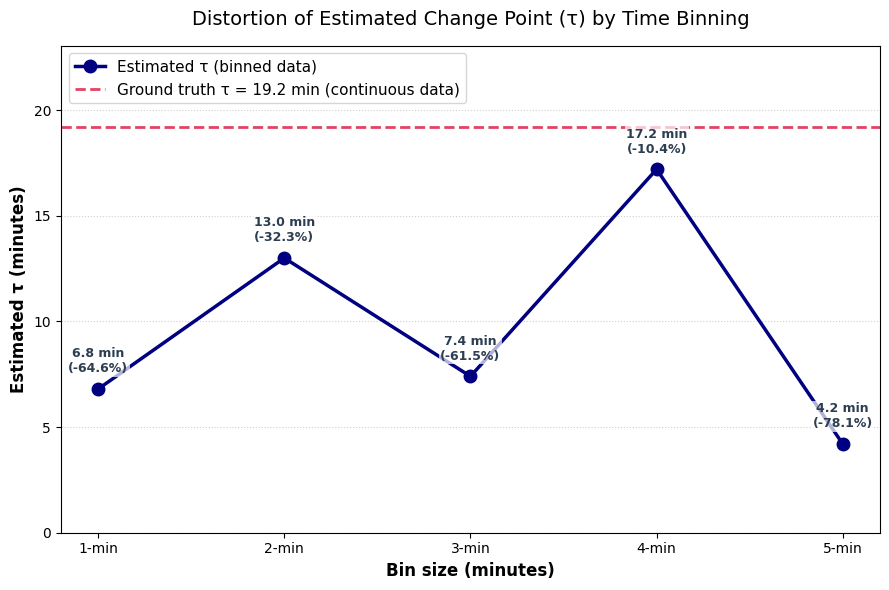

In [27]:
plt.figure(figsize=(9, 6))
plt.plot(bin_sizes, discovered_taus, marker='o', markersize=9, linestyle='-', linewidth=2.5,
         color='navy', label='Estimated τ (binned data)')
plt.axhline(y=ground_truth_tau, color='crimson', linestyle='--', linewidth=2, alpha=0.8,
            label=f'Ground truth τ = {ground_truth_tau:.1f} min (continuous data)')

for i, (bs, tau_est) in enumerate(zip(bin_sizes, discovered_taus)):
    if pd.notna(tau_est):
        distortion = ((tau_est - ground_truth_tau) / ground_truth_tau) * 100
        sign = "+" if distortion > 0 else ""
        label = f"{tau_est:.1f} min\n({sign}{distortion:.1f}%)"
        plt.annotate(label, (bs, tau_est), textcoords="offset points", xytext=(0, 12),
                     ha='center', fontsize=9, fontweight='bold', color='#2c3e50',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.ylim(bottom=0, top=max(discovered_taus + [ground_truth_tau]) * 1.2)
plt.title('Distortion of Estimated Change Point (τ) by Time Binning', fontsize=14, pad=15)
plt.ylabel('Estimated τ (minutes)', fontsize=12, fontweight='bold')
plt.xlabel('Bin size (minutes)', fontsize=12, fontweight='bold')
plt.xticks(bin_sizes, [f"{b}-min" for b in bin_sizes])
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('RQ2_Binning_Deviation.png', dpi=300, bbox_inches='tight')
plt.show()